# Crop Disease Classifier - MobileNetV2 Transfer Learning

**Why MobileNetV2?**
- Very lightweight (~14MB), designed for mobile/edge devices
- Pre-trained on ImageNet (1.2M images, 1000 classes) - powerful feature extractor
- Significantly better than a custom CNN trained from scratch on a small dataset

**Strategy (Two-Phase Training)**
1. **Phase 1 - Feature Extraction**: Freeze MobileNetV2 base, train only the new classification head.
2. **Phase 2 - Fine-Tuning**: Unfreeze top layers and train end-to-end with a very low learning rate.

## 1. Imports & Configuration

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

In [ ]:
# Configuration
DATASET_PATH     = 'PlantVillage'                           # Folder with one sub-folder per class
MODEL_NAME       = 'crop_disease_mobilenet_plantvillage_model.keras'
CLASSES_FILE     = 'plantvillage.txt'

IMG_SIZE         = 224                                 # MobileNetV2 native input size
BATCH_SIZE       = 32
VALIDATION_SPLIT = 0.2

# Phase 1 - head training
PHASE1_EPOCHS    = 15
PHASE1_LR        = 1e-3

# Phase 2 - fine-tuning (unfreeze top layers of base)
PHASE2_EPOCHS    = 20                                  # additional epochs
PHASE2_LR        = 1e-5                                # very low LR
FINE_TUNE_AT     = 100                                 # unfreeze from this layer index onward

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 2. Data Loading & Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=40,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VALIDATION_SPLIT
)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
CLASS_NAMES = list(train_data.class_indices.keys())

print(f'Training samples  : {train_data.samples}')
print(f'Validation samples: {val_data.samples}')
print(f'Number of classes : {NUM_CLASSES}')

Found 4709 images belonging to 50 classes.
Found 1170 images belonging to 50 classes.
Training samples  : 4709
Validation samples: 1170
Number of classes : 50


## 3. Visualize Sample Images

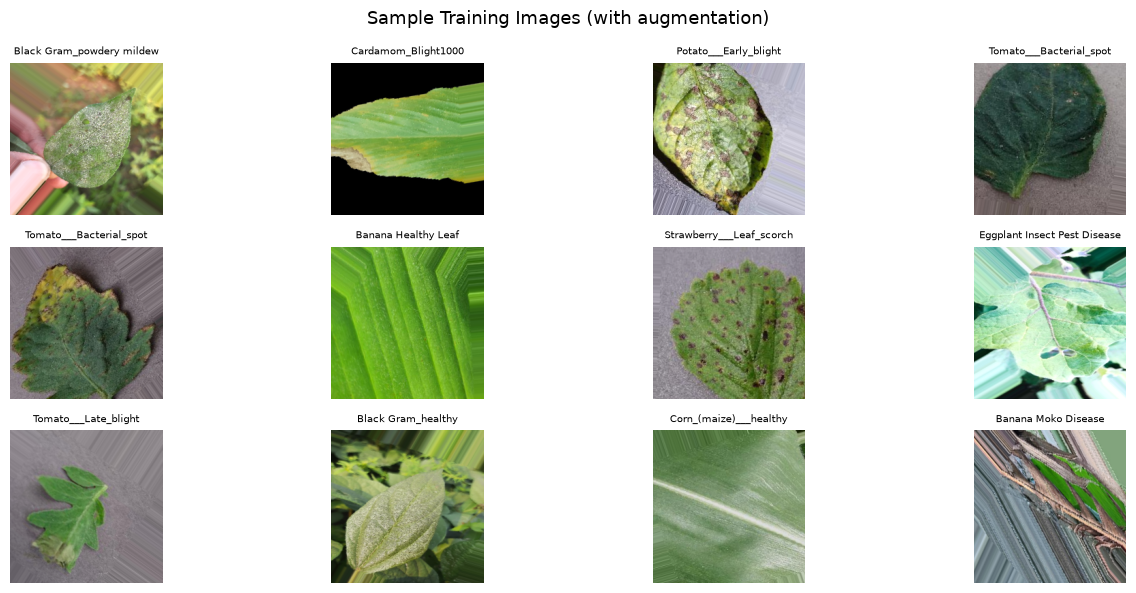

In [ ]:
images, labels = next(train_data)
plt.figure(figsize=(14, 6))
for i in range(min(12, BATCH_SIZE)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    class_idx = np.argmax(labels[i])
    plt.title(CLASS_NAMES[class_idx], fontsize=7)
    plt.axis('off')
plt.suptitle('Sample Training Images (with augmentation)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Build the Model (MobileNetV2 + Custom Head)

In [ ]:
def build_model(num_classes, img_size=224):
    inputs = layers.Input(shape=(img_size, img_size, 3), name='input_image')

    # Scale [0,1] to [-1,1] for MobileNetV2
    x = layers.Lambda(lambda img: img * 2.0 - 1.0, name='mobilenet_preprocess')(inputs)

    # MobileNetV2 backbone - frozen for Phase 1
    base_model = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet',
        pooling=None
    )
    base_model.trainable = False
    x = base_model(x, training=False)

    # Classification head
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)
    x = layers.Dense(128, activation='relu', name='dense_128')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs, outputs, name='CropDisease_MobileNetV2')
    return model, base_model


model, base_model = build_model(NUM_CLASSES, IMG_SIZE)
print(f'Total layers in base model: {len(base_model.layers)}')
model.summary(line_length=80)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Total layers in base model: 154


Model: "CropDisease_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)     │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224 (Functional) │ (None, 7, 7, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)      │ (None, 1280)             │         5,120 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_256 (Dense)                 │ (None, 256)              │       327,936 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_128 (Dense)                 │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_2 (Dropout)               │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ output (Dense)                    │ (None, 50)               │         6,450 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,630,386 (10.03 MB)

 Trainable params: 369,842 (1.41 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 5. Phase 1 - Train Classification Head (Base Frozen)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=PHASE1_LR),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)

cb_phase1 = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_phase1.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

print('Phase 1: Training classification head (base model frozen)...')
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=PHASE1_EPOCHS,
    callbacks=cb_phase1,
    verbose=1
)

Phase 1: Training classification head (base model frozen)...
Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 466ms/step - accuracy: 0.4355 - loss: 2.1544 - top3_acc: 0.6328 - val_accuracy: 0.7239 - val_loss: 0.9479 - val_top3_acc: 0.8991 - learning_rate: 0.0010
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 63s 426ms/step - accuracy: 0.6902 - loss: 1.0084 - top3_acc: 0.8953 - val_accuracy: 0.8162 - val_loss: 0.6155 - val_top3_acc: 0.9436 - learning_rate: 0.0010
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 64s 432ms/step - accuracy: 0.7681 - loss: 0.7441 - top3_acc: 0.9382 - val_accuracy: 0.8308 - val_loss: 0.5190 - val_top3_acc: 0.9624 - learning_rate: 0.0010
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 63s 429ms/step - accuracy: 0.8027 - loss: 0.6436 - top3_acc: 0.9482 - val_accuracy: 0.8444 - val_loss: 0.4901 - val_top3_acc: 0.9624 - learning_rate: 0.0010
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 63s 428ms/step - accuracy: 0.8235 - loss: 0.5682 - top3_acc: 0.9577 - val_accuracy: 0.8419 - val_loss: 0.5385 -

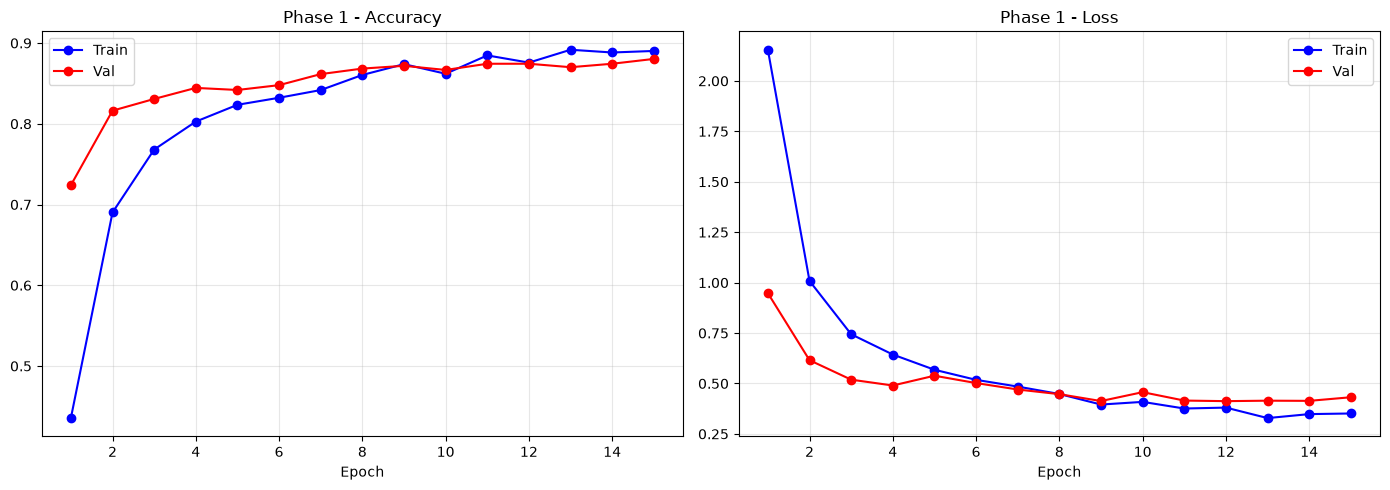

In [ ]:
def plot_history(history, title='Training History', offset=0):
    epochs = range(offset + 1, offset + len(history.history['accuracy']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, history.history['accuracy'],     'b-o', label='Train')
    ax1.plot(epochs, history.history['val_accuracy'], 'r-o', label='Val')
    ax1.set_title(f'{title} - Accuracy'); ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(epochs, history.history['loss'],     'b-o', label='Train')
    ax2.plot(epochs, history.history['val_loss'], 'r-o', label='Val')
    ax2.set_title(f'{title} - Loss'); ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history1, title='Phase 1')

## 6. Phase 2 - Fine-Tune Top Layers of MobileNetV2

Unfrozen layers in base model: 54 / 154
Phase 2: Fine-tuning top layers of MobileNetV2...
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 84s 518ms/step - accuracy: 0.7520 - loss: 0.8653 - top3_acc: 0.9159 - val_accuracy: 0.8513 - val_loss: 0.5981 - val_top3_acc: 0.9556 - learning_rate: 1.0000e-05
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 78s 528ms/step - accuracy: 0.7963 - loss: 0.6800 - top3_acc: 0.9386 - val_accuracy: 0.8342 - val_loss: 0.6799 - val_top3_acc: 0.9521 - learning_rate: 1.0000e-05
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 82s 552ms/step - accuracy: 0.8142 - loss: 0.6136 - top3_acc: 0.9503 - val_accuracy: 0.8427 - val_loss: 0.6311 - val_top3_acc: 0.9513 - learning_rate: 1.0000e-05
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 85s 572ms/step - accuracy: 0.8369 - loss: 0.5542 - top3_acc: 0.9548 - val_accuracy: 0.8521 - val_loss: 0.5892 - val_top3_acc: 0.9556 - learning_rate: 1.0000e-05
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 79s 540ms/step - accuracy: 0.8386 - loss: 0.5160 - top3_acc: 0.959

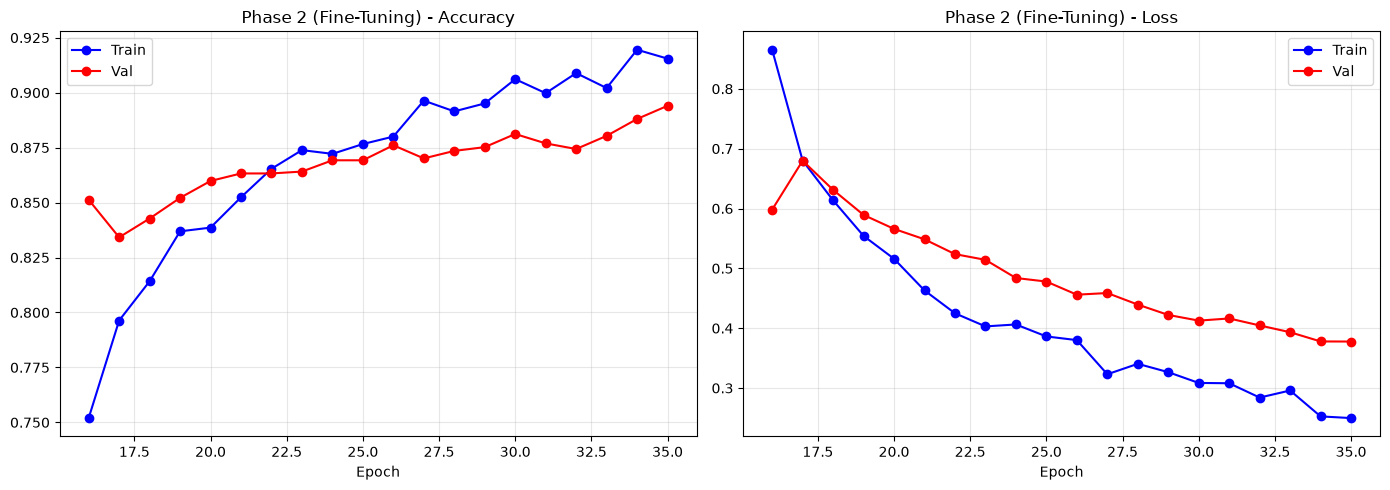

In [ ]:
# Unfreeze top portion of base model
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen layers in base model: {trainable_count} / {len(base_model.layers)}')

model.compile(
    optimizer=optimizers.Adam(learning_rate=PHASE2_LR),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)

cb_phase2 = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-8, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_phase2.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

total_phase1_epochs = len(history1.history['accuracy'])
print('Phase 2: Fine-tuning top layers of MobileNetV2...')
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=PHASE2_EPOCHS,
    callbacks=cb_phase2,
    verbose=1
)

plot_history(history2, title='Phase 2 (Fine-Tuning)', offset=total_phase1_epochs)

## 7. Combined Training Curve

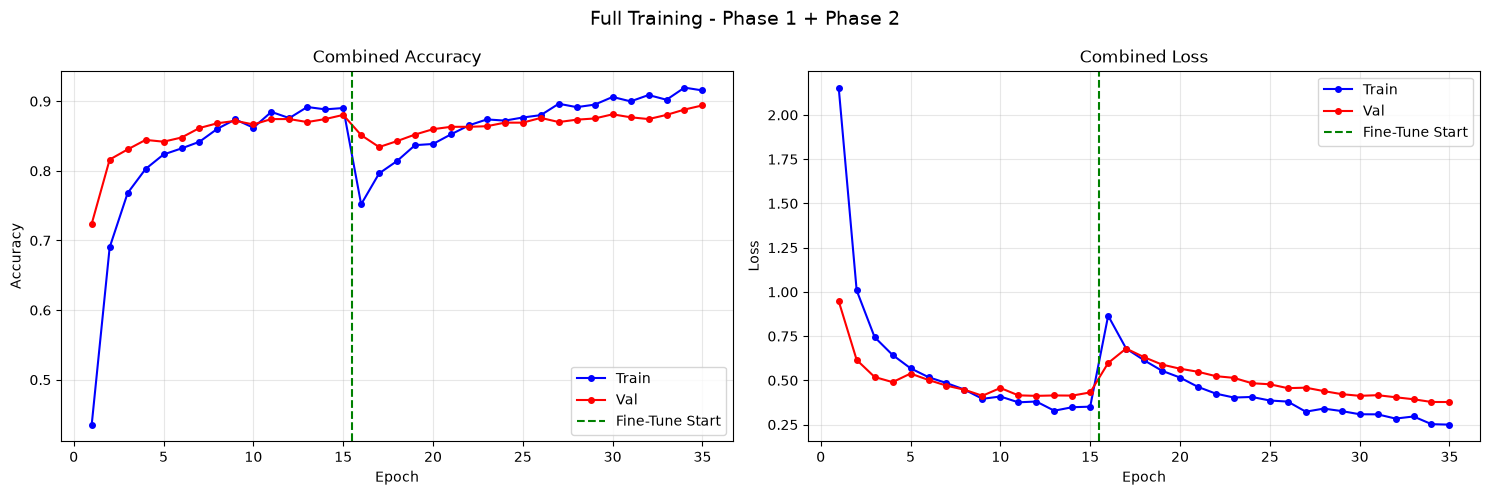

Best Validation Accuracy: 89.40%
Final Training Accuracy : 91.55%


In [ ]:
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
total_epochs = len(acc)
phase2_start = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for ax, tv, vv, ylabel in [
    (ax1, acc, val_acc, 'Accuracy'),
    (ax2, loss, val_loss, 'Loss')
]:
    ax.plot(range(1, total_epochs+1), tv, 'b-o', markersize=4, label='Train')
    ax.plot(range(1, total_epochs+1), vv, 'r-o', markersize=4, label='Val')
    ax.axvline(x=phase2_start+0.5, color='green', linestyle='--', linewidth=1.5, label='Fine-Tune Start')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(f'Combined {ylabel}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Full Training - Phase 1 + Phase 2', fontsize=14)
plt.tight_layout(); plt.show()
print(f'Best Validation Accuracy: {max(val_acc)*100:.2f}%')
print(f'Final Training Accuracy : {acc[-1]*100:.2f}%')

## 8. Evaluate on Validation Set

In [ ]:
val_data.reset()
results = model.evaluate(val_data, verbose=1)
print(f'Validation Loss    : {results[0]:.4f}')
print(f'Validation Accuracy: {results[1]*100:.2f}%')
print(f'Top-3 Accuracy     : {results[2]*100:.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - accuracy: 0.8940 - loss: 0.3777 - top3_acc: 0.9726
Validation Loss    : 0.3777
Validation Accuracy: 89.40%
Top-3 Accuracy     : 97.26%


37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step

Classification Report:
                                                    precision    recall  f1-score   support

                     Banana Black Sigatoka Disease       1.00      0.91      0.95        23
                 Banana Bract Mosaic Virus Disease       0.97      1.00      0.99        37
                               Banana Healthy Leaf       1.00      0.96      0.98        28
                        Banana Insect Pest Disease       0.96      1.00      0.98        23
                               Banana Moko Disease       0.89      0.96      0.93        26
                             Banana Panama Disease       0.90      0.93      0.92        30
                    Banana Yellow Sigatoka Disease       0.94      0.97      0.95        32
                            Black Gram_anthracnose       0.90      1.00      0.95        28
                                Black Gram_healthy       0.68      0.88      0.76        24
             

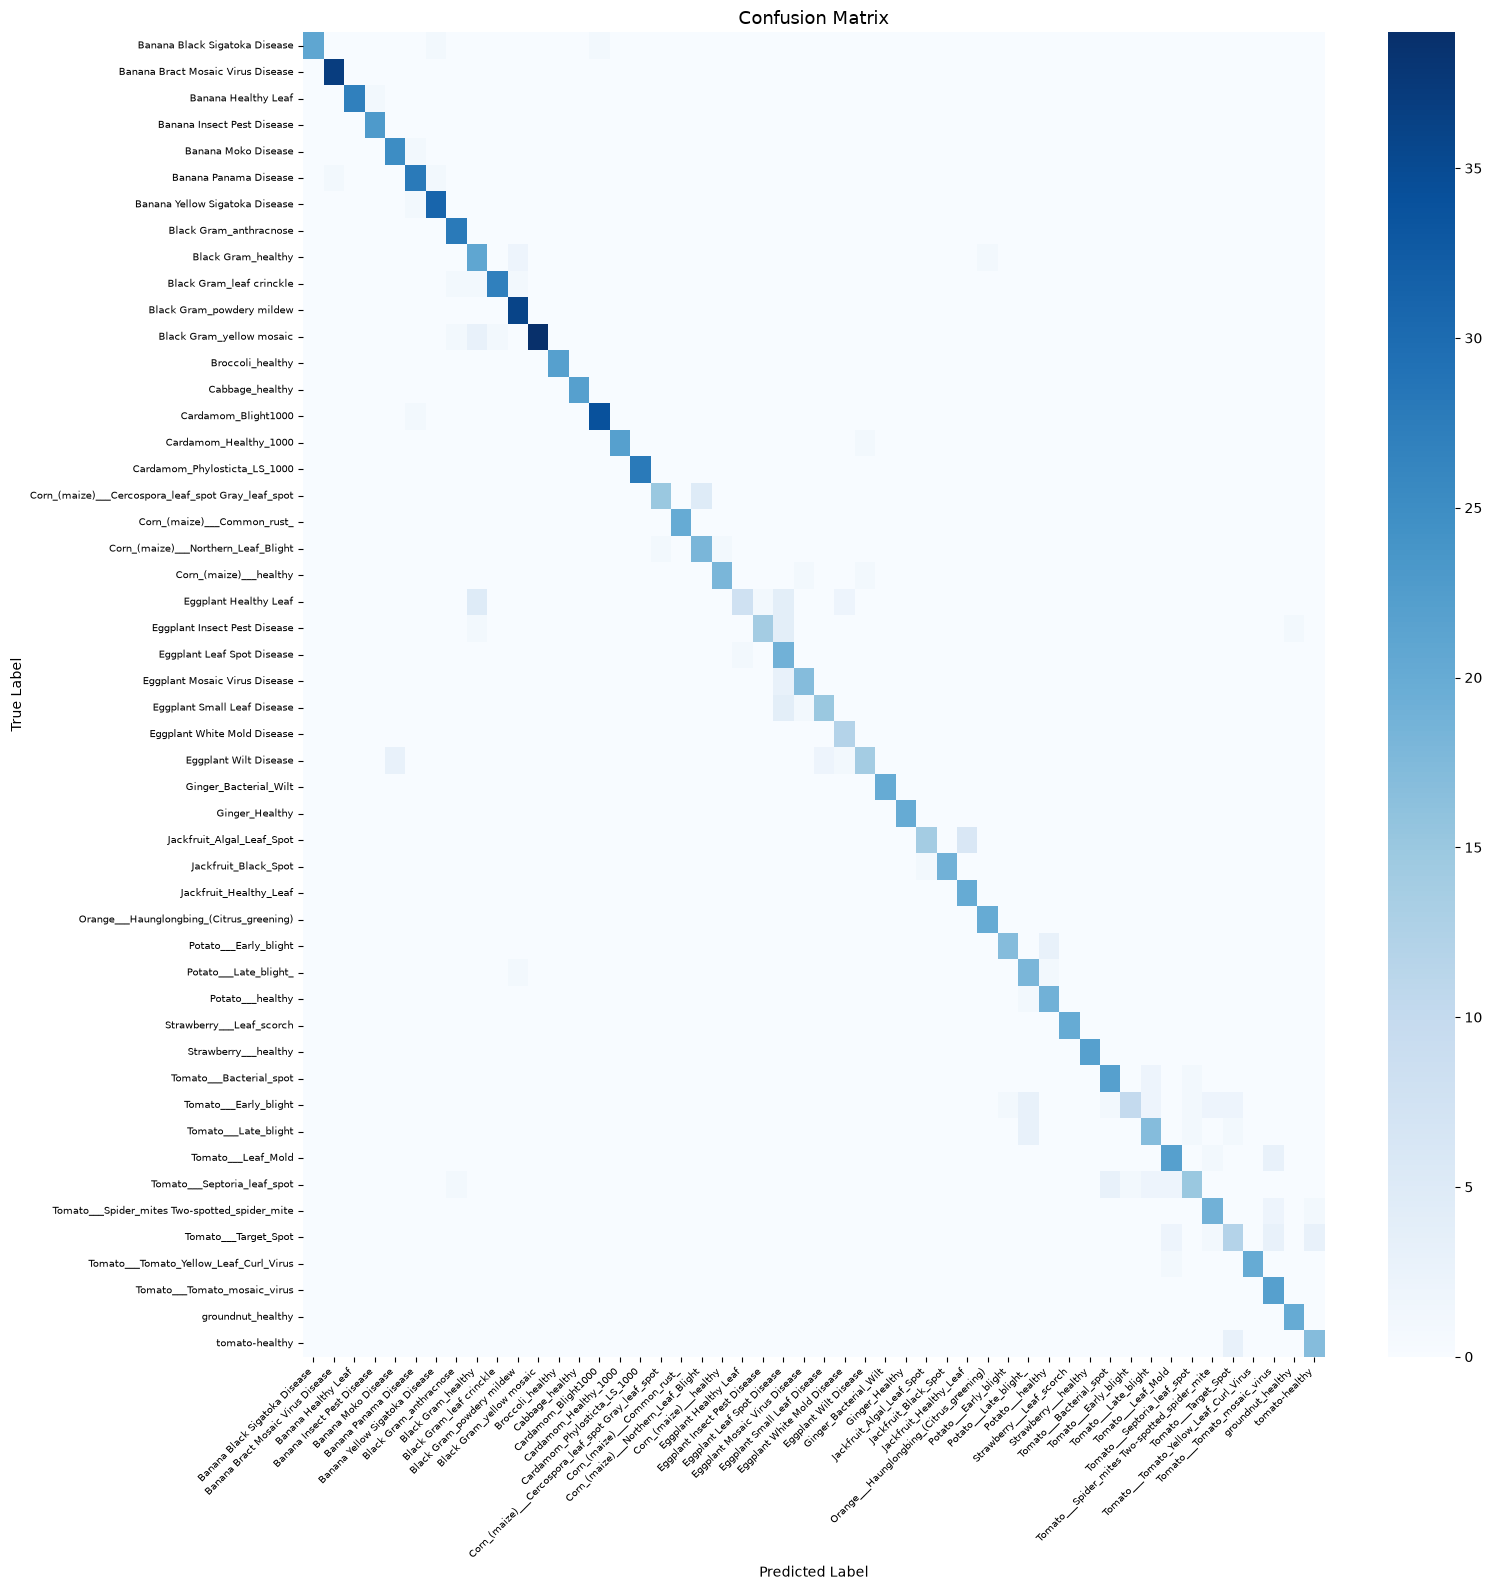

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_data.reset()
y_pred_probs = model.predict(val_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(max(10, NUM_CLASSES // 3), max(8, NUM_CLASSES // 3)))
sns.heatmap(cm, annot=(NUM_CLASSES <= 20), fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=13)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()

## 9. Save Model & Class Labels

In [ ]:
model.save(MODEL_NAME)
print(f'Model saved as: {MODEL_NAME}')

with open(CLASSES_FILE, 'w') as f:
    for cls in CLASS_NAMES:
        f.write(cls + '\n')
print(f'Class labels saved to: {CLASSES_FILE}')

Model saved as: crop_disease_mobilenet_model.keras
Class labels saved to: disease_classes_mobilenet.txt


## 10. Predict on a Single Image

Prediction for: dataset\Banana Black Sigatoka Disease\Augmented Banana Black Sigatoka Disease (1).jpg
  #1  Banana Black Sigatoka Disease             confidence: 98.8%
  #2  Banana Panama Disease                     confidence: 1.2%
  #3  Banana Moko Disease                       confidence: 0.0%


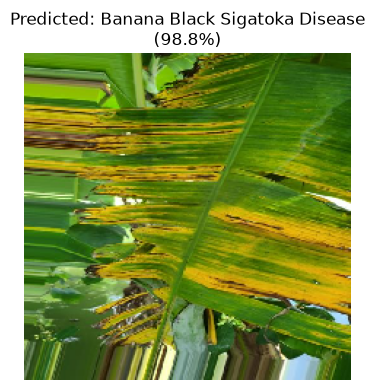

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_disease(img_path, model, class_names, img_size=224, top_k=3):
    img   = keras_image.load_img(img_path, target_size=(img_size, img_size))
    arr   = keras_image.img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)
    preds = model.predict(arr, verbose=0)[0]
    top_idx = np.argsort(preds)[::-1][:top_k]
    print(f'Prediction for: {img_path}')
    for rank, idx in enumerate(top_idx, 1):
        print(f'  #{rank}  {class_names[idx]:<40s}  confidence: {preds[idx]*100:.1f}%')
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'Predicted: {class_names[top_idx[0]]}\n({preds[top_idx[0]]*100:.1f}%)')
    plt.axis('off'); plt.tight_layout(); plt.show()
    return class_names[top_idx[0]], preds[top_idx[0]]


# Quick smoke-test with a random dataset image
sample_path = None
for cls_folder in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, cls_folder)
    if os.path.isdir(folder):
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if files:
            sample_path = os.path.join(folder, files[0])
            break

if sample_path:
    predict_disease(sample_path, model, CLASS_NAMES)
else:
    print('No sample image found - point predict_disease() at your own image.')

# Uncomment to test your own image:
# predict_disease('test_leaf.jpg', model, CLASS_NAMES)

## 11. Tips to Push Accuracy Even Higher

| Technique | Expected Gain |
|-----------|---------------|
| **More data** (>200 images/class) | +5-15% |
| **TTA** - Test-Time Augmentation | +1-3% |
| **Label smoothing** (`label_smoothing=0.1`) | +1-2% |
| **EfficientNetB0** instead of MobileNetV2 | +2-5% |
| **Mix-up / CutMix** augmentation | +2-4% |
| **Class weighting** for imbalanced data | Better per-class recall |